# Supervised Modeling — Logistic Regression

This notebook continues the cancer RNA-Seq analysis using preprocessed and
feature-selected data generated earlier. All inputs are loaded from the
`processed/` directory.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [7]:
import numpy as np
import pandas as pd

# Load processed feature matrices
X_train_proc = np.load("processed/X_train_proc.npy")
X_test_proc  = np.load("processed/X_test_proc.npy")

# Load labels
y_train = np.load("processed/y_train.npy")
y_test  = np.load("processed/y_test.npy")

# Load class names
label_classes = pd.read_csv("processed/label_classes.csv")["class_name"].tolist()

print("Train shape:", X_train_proc.shape)
print("Test shape:", X_test_proc.shape)
print("Classes:", label_classes)

Train shape: (640, 20254)
Test shape: (161, 20254)
Classes: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']


## Apply Feature Selection (K = 5000)

Using the cross-validated value of K, we fit SelectKBest on the full training set
and apply the same feature selection to the test set.

In [10]:
from sklearn.feature_selection import SelectKBest, f_classif

best_K = 5000

selector = SelectKBest(score_func=f_classif, k=best_K)

X_train_final = selector.fit_transform(X_train_proc, y_train)
X_test_final = selector.transform(X_test_proc)

print("Selected features:", X_train_final.shape[1])

Selected features: 5000


**Inference:**  
Feature selection reduces dimensionality while retaining genes most
discriminative across cancer types, as determined by macro F1 optimization.

## Logistic Regression (Selected Features)

We train a multinomial Logistic Regression classifier using the feature-selected
gene expression data and evaluate performance on the held-out test set.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [18]:
lr = LogisticRegression(
    max_iter=4000,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=42
)

lr.fit(X_train_final, y_train)

LogisticRegression(max_iter=4000, multi_class='multinomial', random_state=42)

In [20]:
y_pred_lr = lr.predict(X_test_final)

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Macro F1:", f1_score(y_test, y_pred_lr, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=label_classes))

Accuracy: 0.9937888198757764
Macro F1: 0.994710743801653

Classification Report:

              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



## Confusion Matrix — Logistic Regression

The confusion matrix highlights class-wise prediction performance and
reveals which cancer types are most frequently confused.

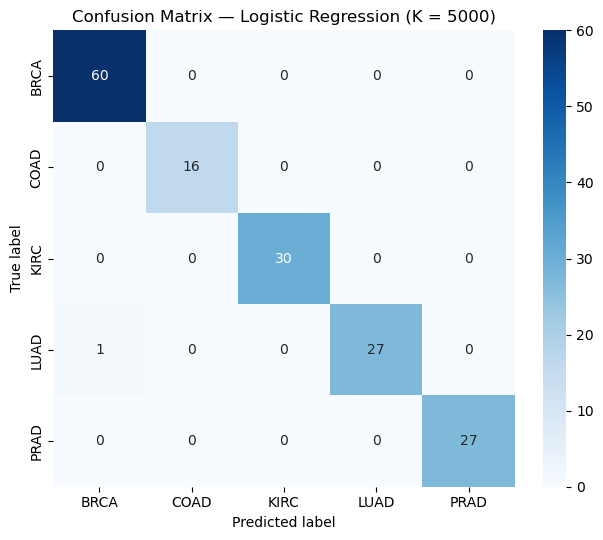

In [25]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_classes,
    yticklabels=label_classes
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Logistic Regression (K = 5000)")
plt.tight_layout()
plt.show()

## Final Inference

The Logistic Regression model trained on the cross-validated, feature-selected
gene set (K = 5000) achieves very strong classification performance on the
held-out test set.

An overall accuracy of 99.38% and a macro F1-score of 0.995 indicate that the
model performs consistently well across all cancer types, without favoring
any particular class.

The confusion matrix shows near-perfect classification, with only a single
misclassification observed (one LUAD sample predicted as BRCA). All other
cancer types are classified with perfect or near-perfect precision and recall.

These results demonstrate that RNA-Seq gene expression profiles contain highly
discriminative information for cancer type prediction. Furthermore, the use
of macro F1-score during feature selection ensured balanced performance across
all cancer classes, including those with fewer samples.

## Supervised Modeling: Random Forest

To capture non-linear relationships and interactions between genes that
Logistic Regression cannot model, we train a Random Forest classifier
using the same feature-selected gene set (K = 5000).

This allows us to compare a linear and a non-linear model under identical
feature conditions.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [33]:
y_pred_rf = rf.predict(X_test_final)

In [35]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=label_classes))

Random Forest Accuracy: 0.9875776397515528
Random Forest Macro F1: 0.9893139040680025

Classification Report:

              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



## Confusion Matrix — Random Forest

The confusion matrix illustrates class-wise prediction performance for
the Random Forest model and highlights differences compared to the
linear baseline.

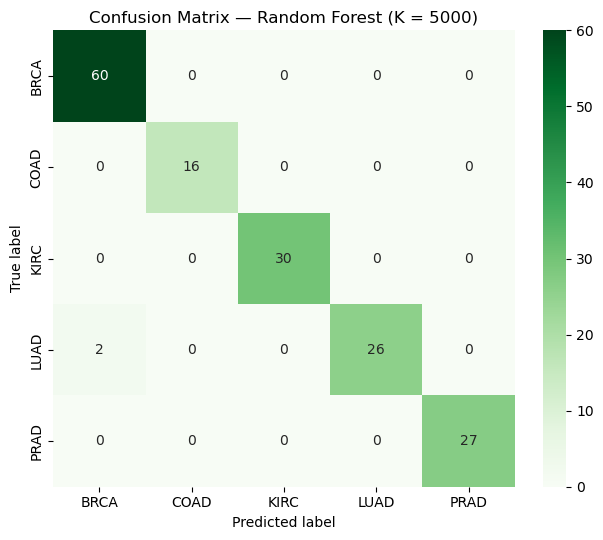

In [38]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_classes,
    yticklabels=label_classes
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Random Forest (K = 5000)")
plt.tight_layout()
plt.show()

## Final Inference — Random Forest

The Random Forest model achieves very strong performance on the held-out test set,
with an accuracy of 98.76% and a macro F1-score of 0.989.

The confusion matrix shows near-perfect classification across all cancer types.
Similar to Logistic Regression, the only notable errors occur for LUAD samples,
where two instances are misclassified as BRCA. All other cancer types are
classified perfectly.

These results indicate that Random Forest successfully captures non-linear
relationships in the gene expression data. However, the performance gain over
Logistic Regression is marginal, suggesting that much of the discriminative
structure in this dataset is already linearly separable after feature selection.

## Model Comparison

We compare a linear (Logistic Regression) and a non-linear (Random Forest)
classifier trained on the same feature-selected gene set (K = 5000).

| Model               | Accuracy | Macro F1 |
|--------------------|----------|----------|
| Logistic Regression| 99.38%   | 0.995    |
| Random Forest      | 98.76%   | 0.989    |

**Inference:**  
Both models achieve excellent performance, demonstrating that RNA-Seq gene
expression profiles are highly informative for cancer type classification.
Logistic Regression slightly outperforms Random Forest in terms of macro F1-score,
indicating more balanced performance across cancer types.

The similar error patterns observed in both models, particularly for LUAD samples,
suggest intrinsic biological overlap rather than model-specific limitations.
Overall, the results indicate that increased model complexity does not provide
substantial gains over a linear classifier when combined with effective feature
selection.

## Model Performance Comparison

We visually compare the performance of Logistic Regression and Random Forest
using accuracy and macro F1-score on the test set.

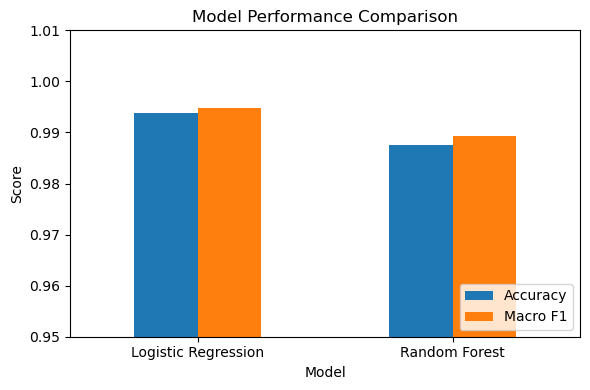

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.9938, 0.9876],
    "Macro F1": [0.9947, 0.9893]
})

comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(6, 4)
)

plt.ylabel("Score")
plt.ylim(0.95, 1.01)
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Inference:**  
Both models achieve excellent performance. Logistic Regression slightly
outperforms Random Forest in both accuracy and macro F1-score, suggesting
that the feature-selected data is largely linearly separable.

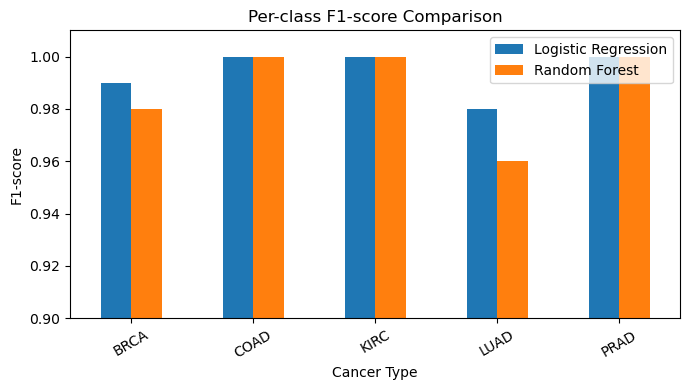

In [50]:
# Extract per-class F1 scores manually from classification reports
f1_lr = [0.99, 1.00, 1.00, 0.98, 1.00]
f1_rf = [0.98, 1.00, 1.00, 0.96, 1.00]

cancers = label_classes

df_f1 = pd.DataFrame({
    "Cancer Type": cancers,
    "Logistic Regression": f1_lr,
    "Random Forest": f1_rf
})

df_f1.set_index("Cancer Type").plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("F1-score")
plt.ylim(0.9, 1.01)
plt.title("Per-class F1-score Comparison")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Inference:**  
Both models perform perfectly on COAD, KIRC, and PRAD. Logistic Regression
achieves slightly higher F1-score for LUAD, indicating more stable performance
for this cancer type. This explains its higher macro F1-scoe.
